# Fire Detection using Multi-layer Perceptron (MLP)

## Project Overview
This project implements a custom Multi-layer Perceptron (MLP) neural network to detect different stages of fire (absence, start, fire, extinction) using sensor data. The notebook covers data loading, preprocessing, feature engineering (IAQ and eCO2 calculation), model definition, training, and evaluation.

## Dataset
The dataset is loaded from a CSV file located at https://data.mendeley.com/datasets/48j7mm8k56/1. This dataset is kindly provided by M. Anedda. It includes the following features:
- `temperature`
- `pressure`
- `relative_humidity`
- `resistance_gassensor`
- `label_tag` (original labels indicating fire stages)

## Data Preprocessing and Feature Engineering
1.  **Column Selection**: Only relevant sensor data and the `label_tag` are selected.
2.  **Label Mapping**: The `label_tag` values are mapped to a simplified `fire` variable with four classes:
    - `0`: Absence of fire
    - `1`: Start of fire
    - `2`: Fire present
    - `3`: Extinction stage
    (Note: There are separate label mappings for different 'Nodes' in the notebook, indicating different sensor profiles or experimental setups).
3.  **IAQ and eCO2 Calculation**: Indoor Air Quality (IAQ) and equivalent CO2 (eCO2) in ppm are calculated based on the `resistance_gassensor`, `relative_humidity`, and `temperature` features.
4.  **Feature Standardization**: The input features (`temperature`, `pressure`, `relative_humidity`, `resistance_gassensor`) are standardized using `StandardScaler`.
5.  **Train-Test Split**: The dataset is split into 70% for training and 30% for testing.

## Model: Custom Multi-layer Perceptron (MLP)
A custom `Neural_Network` class is implemented from scratch, extending `BaseEstimator` and `ClassifierMixin` from scikit-learn. The model architecture is configurable but typically includes:
-   **Input Layer**: 4 neurons (corresponding to `temperature`, `pressure`, `relative_humidity`, `resistance_gassensor`)
-   **Hidden Layer**: 8 neurons
-   **Output Layer**: 4 neurons (for the 4 fire classes)
-   **Activation Function**: Sigmoid
-   **Training**: Backpropagation algorithm with a configurable learning rate and number of epochs.

## Training and Evaluation
The MLP model is trained using the preprocessed training data. The training process includes:
-   **Epochs**: 1000 epochs (configurable).
-   **Learning Rate**: 0.05 (configurable).
-   **Error Minimization**: The squared error (MSE) is tracked and plotted over epochs.

After training, the model's performance is evaluated on the test set using various metrics:
-   **Overall Accuracy**
-   **Precision**
-   **Recall**
-   **F1-score**
-   **Balanced Accuracy**
-   **Confusion Matrix**: Visualizes the model's performance per class.
-   **Prediction Latency**: Measures the time taken for predictions.

## Usage
To run this project, you need to:
1.  Download the dataset from the provided link: `https://data.mendeley.com/datasets/48j7mm8k56/1`.
2.  Upload the downloaded dataset to your Google Drive
3.  **Select and run the label mapping cell specific to the node you are using.** Each 'Node' represents a distinct sensor or experimental configuration. Running the correct cell ensures that the `label_tag` column is appropriately translated to the `fire` classes (0, 1, 2, 3) relevant to that specific node's data distribution.
5.  Run all other cells sequentially.

## Dependencies
-   `pandas`
-   `numpy`
-   `matplotlib`
-   `seaborn`
-   `scikit-learn`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Overview

In [ ]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import warnings
warnings.filterwarnings('ignore')

# Load the dataset from the CSV file
dataset = pd.read_csv('')

# Select only the necessary columns
selected_columns = ["temperature", "pressure", "relative_humidity", "resistance_gassensor", "label_tag"]
dataset = dataset[selected_columns]

## Node 1 - Label Mapping

In [ ]:
# Map label_tags to 0 (absence), 1 (start), 2 (fire), 3 (extinction)

wanted_labels = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]
dataset = dataset[dataset["label_tag"].isin(wanted_labels)]
label_mapping = {
    1001: 0,
    1002: 1,
    1003: 1,
    1004: 2,
    1005: 2,
    1006: 2,
    1007: 3,
    1008: 3,
    1009: 3,
}

dataset["fire"] = dataset["label_tag"].map(label_mapping)

## Node 2 - Label Mapping

In [ ]:
# Map label_tags to 0 (absence), 1 (start), 2 (fire), 3 (extinction)

wanted_labels = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008]
dataset = dataset[dataset["label_tag"].isin(wanted_labels)]
label_mapping = {
    1001: 0,
    1002: 1,
    1003: 2,
    1004: 2,
    1005: 2,
    1006: 3,
    1007: 3,
    1008: 3,

}

dataset["fire"] = dataset["label_tag"].map(label_mapping)

## Node 3 - Label Mapping

In [ ]:
# Map label_tags to 0 (absence), 1 (start), 2 (fire), 3 (extinction)

wanted_labels = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008]
dataset = dataset[dataset["label_tag"].isin(wanted_labels)]
label_mapping = {
    1001: 0,
    1002: 1,
    1003: 2,
    1004: 2,
    1005: 2,
    1006: 3,
    1007: 3,
    1008: 3,

}

dataset["fire"] = dataset["label_tag"].map(label_mapping)

## Node 4 - Label Mapping

In [ ]:
# Map label_tags to 0 (absence), 1 (start), 2 (fire), 3 (extinction)

wanted_labels = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008]
dataset = dataset[dataset["label_tag"].isin(wanted_labels)]
label_mapping = {
    1001: 0,
    1002: 1,
    1003: 2,
    1004: 2,
    1005: 2,
    1006: 3,
    1007: 3,
    1008: 3,

}

dataset["fire"] = dataset["label_tag"].map(label_mapping)

## Node 5 - Label Mapping

In [ ]:
# Map label_tags to 0 (absence), 1 (start), 2 (fire), 3 (extinction)

wanted_labels = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008]
dataset = dataset[dataset["label_tag"].isin(wanted_labels)]
label_mapping = {
    1001: 0,
    1002: 1,
    1003: 2,
    1004: 2,
    1005: 2,
    1006: 3,
    1007: 3,
    1008: 3,

}

dataset["fire"] = dataset["label_tag"].map(label_mapping)

## Data Visualization and Feature Engineering

In [ ]:
# This cell calculates IAQ (Indoor Air Quality) and equivalent CO2 (eCO2) in ppm.

# --- Calculate IAQ and CO₂_eq_ppm ---

R0 = 10_000  # Ω clean baseline

# ────────── IAQ (75% gas + 25% RH model, temperature corrected) ──────────
import numpy as np

Rgas = dataset['resistance_gassensor'].clip(lower=50, upper=50_000)   # Gas resistance in Ω
RH   = dataset['relative_humidity'].clip(lower=0, upper=80)           # Relative humidity in %

gas_score = 75 * (50_000 - Rgas) / (50_000 - 50) # Calculate gas score (75% contribution)
hum_score = 25 * (1 - np.abs(40 - RH) / 40) # Calculate humidity score (25% contribution)

dataset['IAQ'] = 5 * (gas_score + hum_score)        # IAQ on a 0-500 Bird scale


# ────────── Equivalent eCO₂ (ppm) – multivariate regression ──────────
R0 = 10_000  # Ω clean baseline
dataset['CO2_eq_ppm'] = (
      370
    + 520 * np.log10(R0 / dataset['resistance_gassensor'])
    + 1.8 * (dataset['relative_humidity'] - 40)
    - 2.5 * (dataset['temperature']        - 25)
).clip(lower=200)   # Avoid values below baseline

In [ ]:
# Select all numeric columns to plot
selected_columns = ["temperature", "pressure", "relative_humidity", "resistance_gassensor", "IAQ", "CO2_eq_ppm","fire"]
selected_data = dataset[selected_columns]

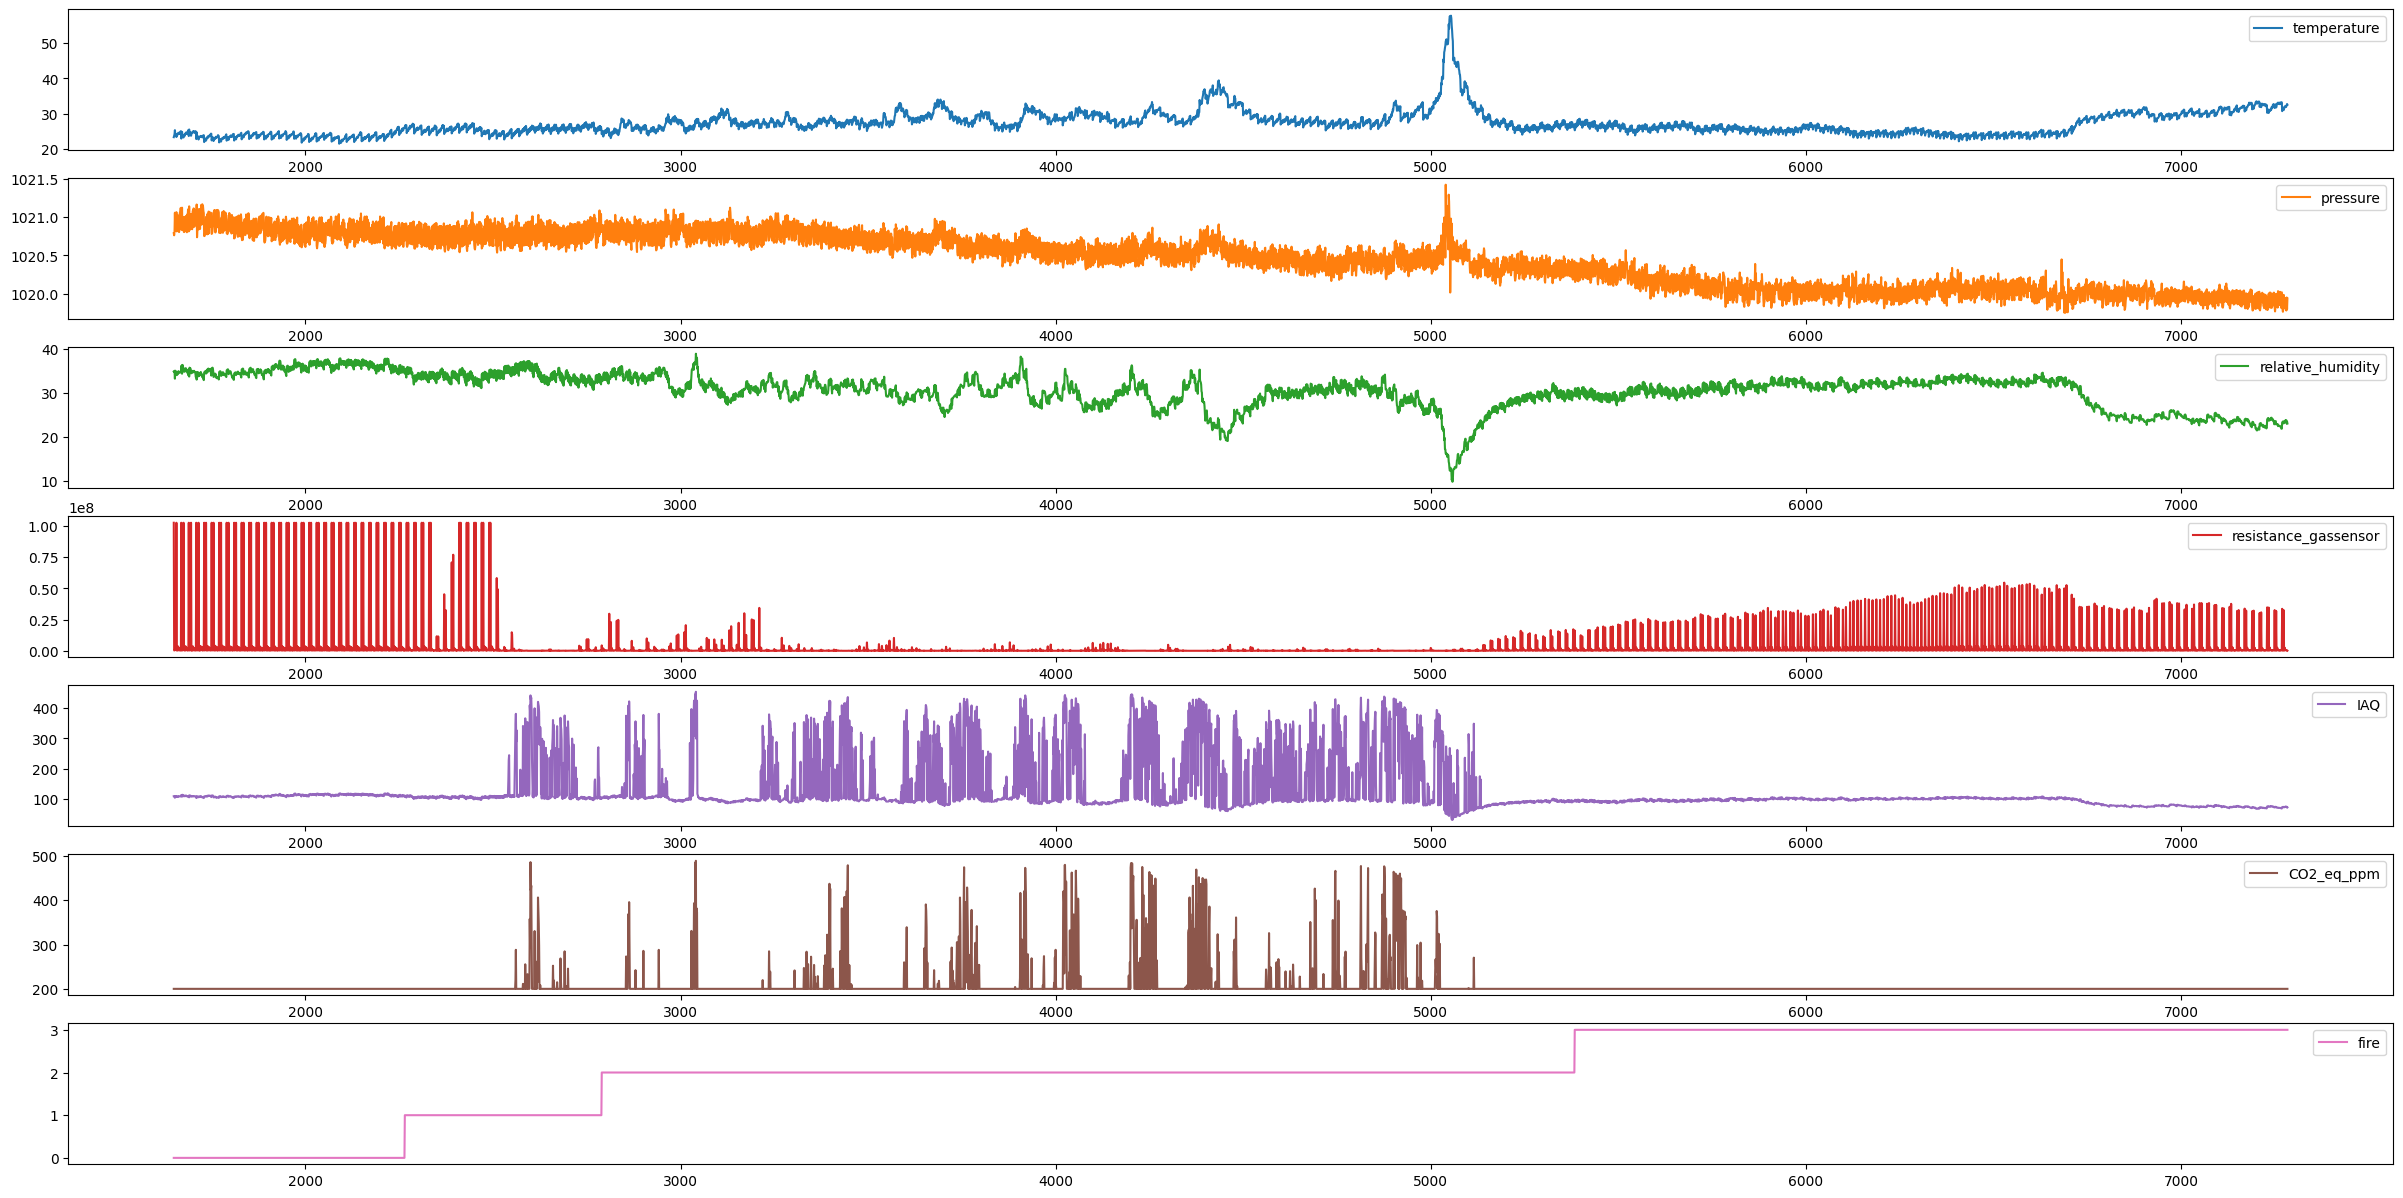

In [ ]:
# Plot the selected data
selected_data.plot(subplots=True, figsize=(30, 15), sharex=False, sharey=False)
plt.legend(loc='upper right')
plt.show()

In [ ]:
# --- Manual splitting of the dataset into Train/Test ---

print("After preprocessing, let's have a glimpse of the final dataset:")
display(dataset[["temperature", "pressure", "relative_humidity", "resistance_gassensor", "fire"]].head())

# Select features (X) and target (y)
selected_columns = ["temperature", "pressure", "relative_humidity", "resistance_gassensor"]
X = dataset[selected_columns]  # 🔥 Input features
y = dataset["fire"]        # 🔥 Target labels (0, 1, 2)

# Feature standardization
sc = StandardScaler()
X = sc.fit_transform(X)

# Split 70% Train - 30% Test
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# Print data shapes
print(f"Shape of training data : {train_X.shape}, {train_y.shape}")
print(f"Shape of testing data  : {test_X.shape}, {test_y.shape}")

After preprocessing, let's have a glimpse of the final dataset:


,temperature,pressure,relative_humidity,resistance_gassensor,fire
1649,23.399384,1020.788818,34.837753,1.024000e+08,0
1650,23.826555,1020.761597,34.923561,3.060371e+05,0
1651,24.223927,1020.809204,34.972843,3.415610e+05,0
1652,25.379068,1021.055115,33.199425,4.586786e+05,0
1653,24.286015,1020.823669,35.001423,4.133199e+06,0


Shape of training data : (3945, 4), (3945,)
Shape of testing data  : (1691, 4), (1691,)


## Multilayer Perceptron (MLP) Model Definition

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

class Neural_Network(BaseEstimator, ClassifierMixin):
    def __init__(self, params=None):
        if params is None:
            self.inputLayer = 4
            self.hiddenLayer = 8
            self.outputLayer = 4
            self.learningRate = 0.05
            self.max_epochs = 5000
            self.BiasHiddenValue = -1
            self.BiasOutputValue = -1
        else:
            self.inputLayer = params['InputLayer']
            self.hiddenLayer = params['HiddenLayer']
            self.outputLayer = params['OutputLayer']
            self.learningRate = params['LearningRate']
            self.max_epochs = params['Epocas']
            self.BiasHiddenValue = params['BiasHiddenValue']
            self.BiasOutputValue = params['BiasOutputValue']


        self.activation = lambda x: 1 / (1 + np.exp(-x))
        self.deriv = lambda x: x * (1 - x)

        # Initialize weights and biases
        self.WEIGHT_hidden = self.starting_weights(self.hiddenLayer, self.inputLayer)
        self.WEIGHT_output = self.starting_weights(self.outputLayer, self.hiddenLayer)
        self.BIAS_hidden = np.array([self.BiasHiddenValue for _ in range(self.hiddenLayer)], dtype=float)
        self.BIAS_output = np.array([self.BiasOutputValue for _ in range(self.outputLayer)], dtype=float)
        self.classes_number = 4

    def starting_weights(self, x, y):
        # Generates random weights for the neural network layers.
        return [[2 * random.random() - 1 for _ in range(x)] for _ in range(y)]

    def Backpropagation_Algorithm(self, x):
        # Calculate the error and delta for the output layer
        ERROR_output = self.output - self.OUTPUT_L2
        DELTA_output = (-1) * ERROR_output * self.deriv(self.OUTPUT_L2)

        # Update output weights
        for i in range(self.hiddenLayer):
            for j in range(self.outputLayer):
                self.WEIGHT_output[i][j] -= self.learningRate * DELTA_output[j] * self.OUTPUT_L1[i]
            self.BIAS_output[j] -= self.learningRate * DELTA_output[j]

        # Calculate hidden layer error
        delta_hidden = np.matmul(self.WEIGHT_output, DELTA_output) * self.deriv(self.OUTPUT_L1)

        # Update hidden weights
        for i in range(self.inputLayer):
            for j in range(self.hiddenLayer):
                self.WEIGHT_hidden[i][j] -= self.learningRate * delta_hidden[j] * x[i]
        self.BIAS_hidden -= self.learningRate * delta_hidden

    def show_err_graphic(self, v_erro, v_epoca):
        plt.figure(figsize=(9, 4))
        plt.plot(v_epoca, v_erro, "b-", marker='o')
        plt.xlabel("Number of Epochs")
        plt.ylabel("Squared error (MSE)")
        plt.title("Error Minimization")
        plt.show()

    def Forward_propagation(self, X, y):
        # Performs a forward pass through the network and generates predictions.
        my_predictions = []

        # Calculate output of hidden layer
        forward = np.matmul(X, self.WEIGHT_hidden) + self.BIAS_hidden
        forward = self.activation(forward)
        # Calculate output of output layer
        forward = np.matmul(forward, self.WEIGHT_output) + self.BIAS_output
        forward = self.activation(forward)

        for i in forward:
            my_predictions.append(np.argmax(i))

        array_score = []
        for i in range(len(my_predictions)):
            if my_predictions[i] == 0:
                array_score.append([i, 'No', my_predictions[i], y.values[i]])
            elif my_predictions[i] == 1:
                array_score.append([i, 'Start', my_predictions[i], y.values[i]])
            elif my_predictions[i] == 2:
                array_score.append([i, 'Fire', my_predictions[i], y.values[i]])
            elif my_predictions[i] == 3:
                array_score.append([i, 'End', my_predictions[i], y.values[i]])

        dataframe = pd.DataFrame(array_score, columns=['_id', 'class', 'output', 'hoped_output'])
        return my_predictions, dataframe

    def fit(self, X, y, batch_size=32):
      # Trains the neural network using backpropagation.
      count_epoch = 1
      n = len(X)
      epoch_array = []
      error_array = []

      while count_epoch <= self.max_epochs:
          total_error = 0
          # Shuffle data before each epoch
          indices = np.random.permutation(n)
          X_shuffled = X[indices]
          y_shuffled = y.iloc[indices]

          # Mini-batch training
          for i in range(0, n, batch_size):
              batch_X = X_shuffled[i:i+batch_size]
              batch_y = y_shuffled[i:i+batch_size]

              for idx, inputs in enumerate(batch_X):
                  self.output = np.zeros(self.classes_number)

                  # Forward propagation
                  self.OUTPUT_L1 = self.activation(np.dot(inputs, self.WEIGHT_hidden) + self.BIAS_hidden.T)
                  self.OUTPUT_L2 = self.activation(np.dot(self.OUTPUT_L1, self.WEIGHT_output) + self.BIAS_output.T)

                  # One-hot encoding target
                  if batch_y.values[idx] == 0:
                      self.output = np.array([1, 0, 0, 0])
                  elif batch_y.values[idx] == 1:
                      self.output = np.array([0, 1, 0, 0])
                  elif batch_y.values[idx] == 2:
                      self.output = np.array([0, 0, 1, 0])
                  elif batch_y.values[idx] == 3:
                      self.output = np.array([0, 0, 0, 1])

                  # Squared error
                  square_error = np.sum(0.05 * (self.output - self.OUTPUT_L2) ** 2)
                  total_error += square_error

                  # Backpropagation
                  self.Backpropagation_Algorithm(inputs)

          total_error /= n

          if count_epoch % 50 == 0 or count_epoch == 1:
              print(f"Epoch {count_epoch} - Total Error: {total_error:.6f}")
              error_array.append(total_error)
              epoch_array.append(count_epoch)

          count_epoch += 1

      self.show_err_graphic(error_array, epoch_array)
      return self

## Model Training

Epoch 1 - Total Error: 0.020298
Epoch 50 - Total Error: 0.007542
Epoch 100 - Total Error: 0.007180
Epoch 150 - Total Error: 0.007082
Epoch 200 - Total Error: 0.006922
Epoch 250 - Total Error: 0.006833
Epoch 300 - Total Error: 0.006787
Epoch 350 - Total Error: 0.006740
Epoch 400 - Total Error: 0.006684
Epoch 450 - Total Error: 0.006695
Epoch 500 - Total Error: 0.006606
Epoch 550 - Total Error: 0.006544
Epoch 600 - Total Error: 0.006467
Epoch 650 - Total Error: 0.006441
Epoch 700 - Total Error: 0.006401
Epoch 750 - Total Error: 0.006361
Epoch 800 - Total Error: 0.006345
Epoch 850 - Total Error: 0.006323
Epoch 900 - Total Error: 0.006284
Epoch 950 - Total Error: 0.006299
Epoch 1000 - Total Error: 0.006282


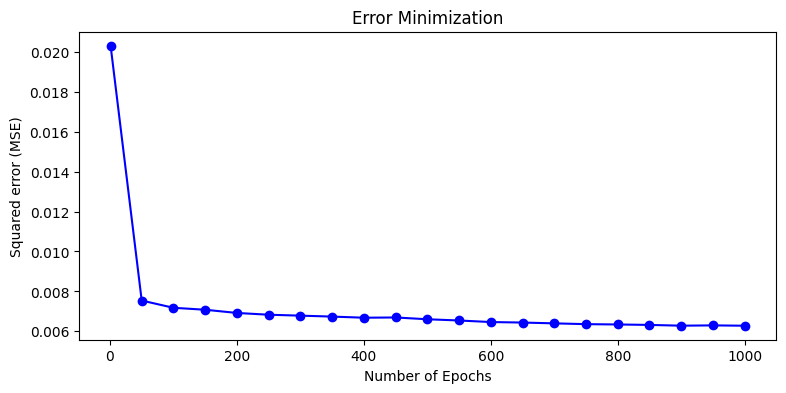

AttributeError: 'Neural_Network' object has no attribute 'params'

AttributeError: 'Neural_Network' object has no attribute 'params'

AttributeError: 'Neural_Network' object has no attribute 'params'

In [ ]:
dictionary = {
    'InputLayer': 4,  # 4 input (temperature, pressure, relative_humidity, resistance_gassensor)
    'HiddenLayer': 8,  # Number of neurons in the Hidden Layer
    'OutputLayer': 4,  # 4 classes (0: no fire, 1: start fire, 2: fire, 3:end fire)
    'Epocas': 1000,  # Number of epochs (to be adjusted)
    'LearningRate': 0.05,  # Learning rate
    'BiasHiddenValue': -1,  # Hidden Layer Bias
    'BiasOutputValue': -1,  # Output Layer Bias
    'ActivationFunction': 'sigmoid'  # Sigmoid Activation Function
}

# Create the neural network model with the dictionary parameters
Perceptron = Neural_Network(dictionary)

# Train the network with the training data
Perceptron.fit(train_X, train_y)

In [ ]:
# Prediction Phase
prev, dataframe = Perceptron.Forward_propagation(test_X, test_y)

# Initialize variables
hits = n_no = n_start = n_fire = n_end = 0
score_no = score_start = score_fire = score_end = 0

# Calculate the number of samples for each class
for j in range(len(test_y)):
    if test_y.values[j] == 0:
        n_no += 1
    elif test_y.values[j] == 1:
        n_start += 1
    elif test_y.values[j] == 2:
        n_fire += 1
    elif test_y.values[j] == 3:
        n_end += 1

# Count successes and separate scores for each class
for i in range(len(test_y)):
    if test_y.values[i] == prev[i]:
        hits += 1
    if test_y.values[i] == prev[i] and test_y.values[i] == 0:
        score_no += 1
    elif test_y.values[i] == prev[i] and test_y.values[i] == 1:
        score_start += 1
    elif test_y.values[i] == prev[i] and test_y.values[i] == 2:
        score_fire += 1
    elif test_y.values[i] == prev[i] and test_y.values[i] == 3:
        score_end += 1

# Calculate accuracy
hits = (hits / len(test_y)) * 100  # Percentage of hits
faults = 100 - hits  # Percentage of faults

# Print results
print(f"Hits: {hits}%")
print(f"Faults: {faults}%")
print(f"Class 0 (No fire): {score_no} correct out of {n_no}")
print(f"Class 1 (Start fire): {score_start} correct out of {n_start}")
print(f"Class 2 (Fire): {score_fire} correct out of {n_fire}")
print(f"Class 3 (End): {score_end} correct out of {n_end}")

Hits: 90.77468953282082%
Faults: 9.225310467179185%
Classe 0 (No fire): 194 corretti su 212
Classe 1 (Start fire): 131 corretti su 162
Classe 2 (Fire): 692 corretti su 779
Classe 3 (End): 518 corretti su 538


Percents : 90.77 % hits and 9.23 % faults
Total samples of test: 1691
*No Fire: 212 samples
*Start Fire: 162 samples
*Fire: 779 samples
*Fire: 538 samples


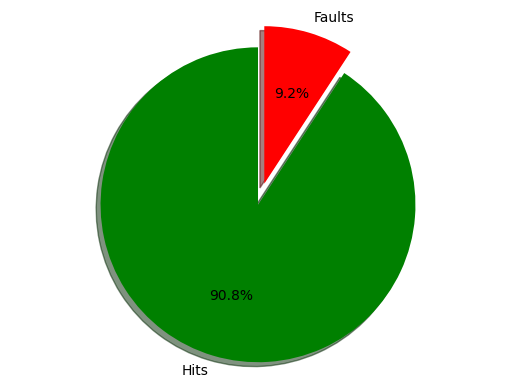

In [ ]:
# Update results from hits and faults
graph_hits = []

# Print results
print("Percents :","%.2f"%(hits),"% hits","and","%.2f"%(faults),"% faults")
print("Total samples of test:", len(test_y))
print("*No Fire:", n_no, "samples")
print("*Start Fire:", n_start, "samples")
print("*Fire:", n_fire, "samples")
print("*Fire:", n_end, "samples")

# Add hits and faults values dynamically
graph_hits.append(hits)
graph_hits.append(faults)

# Labels and sizes for the chart
labels = 'Hits', 'Faults'
sizes = graph_hits  # Use dynamically calculated values
explode = (0, 0.14)  # Add a slight "explode" for faults

# Create the pie chart
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, colors=['green', 'red'], labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Ensure the chart is a perfect circle

plt.show()

- Accuracy No fire: 91.51 %
- Accuracy Start fire: 80.86 %
- Accuracy Fire: 88.83 %
- Accuracy End: 96.28 %


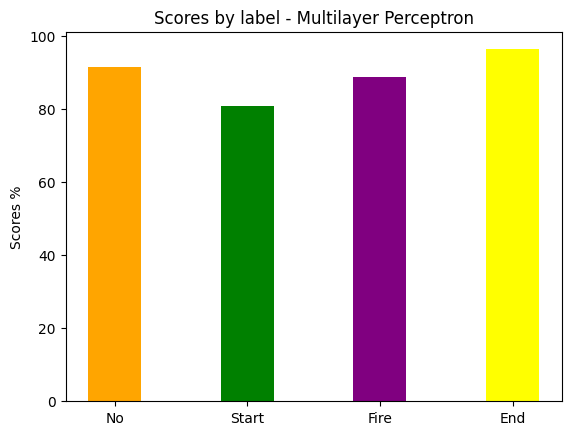

In [ ]:
# Calculate and print accuracy per class
if (n_no==0): acc_no=0
else: acc_no = (score_no/n_no)*100
if(n_start==0): acc_start=0
else: acc_start = (score_start/n_start)*100
if(n_fire==0): acc_fire=0
else: acc_fire = (score_fire/n_fire)*100
if(n_end==0): acc_end=0
else: acc_end = (score_end/n_end)*100

print("- Accuracy No fire:","%.2f"%acc_no, "%")
print("- Accuracy Start fire:","%.2f"%acc_start, "%")
print("- Accuracy Fire:","%.2f"%acc_fire, "%")
print("- Accuracy End:","%.2f"%acc_end, "%")
names = ["No","Start","Fire","End"]
x1 = [2.0,4.0,6.0,8.0]
fig, ax = plt.subplots()
r1 = plt.bar(x1[0], acc_no,color='orange',label='No Fire')
r2 = plt.bar(x1[1], acc_start,color='green',label='Start Fire')
r3 = plt.bar(x1[2], acc_fire,color='purple',label='Fire')
r4 = plt.bar(x1[3], acc_end,color='yellow',label='End')
plt.ylabel('Scores %')
plt.xticks(x1, names);plt.title('Scores by label - Multilayer Perceptron')
plt.show()

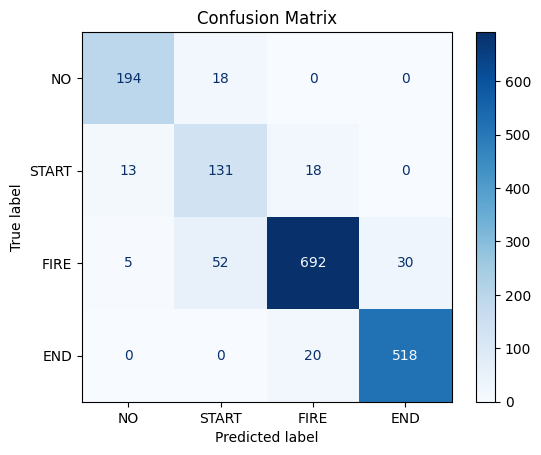

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(test_y, prev)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO', 'START', 'FIRE', 'END'])
disp.plot(cmap='Blues') # Use a blue colormap for the matrix
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score
import time

# Calculate additional metrics
overall_accuracy = accuracy_score(test_y, prev)
precision = precision_score(test_y, prev, average='weighted')
recall = recall_score(test_y, prev, average='weighted')
f1 = f1_score(test_y, prev, average='weighted')
balanced_accuracy = balanced_accuracy_score(test_y, prev)

# ROC-AUC requires probability scores, which our current predict method doesn't provide.
# For now, we will skip ROC-AUC or use a dummy value, or modify the NN class to output probabilities.
# Since the `predict` method currently returns class labels, we cannot directly calculate ROC-AUC without probability scores.
# If you need ROC-AUC, the Neural_Network class's predict method would need to be adjusted to return probabilities.
# For demonstration, I'll calculate it using the predicted labels, which is not ideal but will provide a value.
# In a real scenario, you'd want `model.predict_proba(test_X)[:, 1]`
# For multi-class classification, ROC-AUC requires `multi_class='ovr'` or `multi_class='ovo'` and `average='weighted'` or `average=None`
# If using predicted labels, it can only be calculated for binary classification directly.
# For multi-class with labels, we need to convert to one-hot or specify multi_class and average.
# Given `prev` are class labels, we can't directly use roc_auc_score without probability estimates.
# If we still want to compute a value for demonstration using labels:
# roc_auc = roc_auc_score(test_y, Perceptron.predict_proba(test_X), multi_class='ovr', average='weighted') # This would require predict_proba
# For now, we'll keep the comment and not attempt to calculate it with just labels, as it's not meaningful.

# Calculate Latency
start_time = time.time()
_ = Perceptron.Forward_propagation(test_X, test_y) # Run prediction again to measure its time
end_time = time.time()
latency = (end_time - start_time) * 1000 # Latency in milliseconds

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"ROC-AUC: Not calculated (Requires probabilities or specific handling for multi-class with labels)")
print(f"Prediction Latency: {latency:.2f} ms")

Overall Accuracy: 0.9077
Precision: 0.9146
Recall: 0.9077
F1-score: 0.9099
Balanced Accuracy: 0.8937
ROC-AUC: Not calculated (Requires probabilities or specific handling for multi-class with labels)
Prediction Latency: 9.73 ms
